In [ ]:
%pip install pandas geopandas matplotlib geodatasets scikit-learn duckdb numpy geopy

In [ ]:
%pip install "numpy<2" --force-reinstall

In [57]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import geodatasets
from geodatasets import get_path
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import duckdb
import math
from sklearn.cluster import HDBSCAN
import numpy as np
from geopy.distance import geodesic
from matplotlib.lines import Line2D
from sklearn_extra.cluster import KMedoids
from sklearn.metrics.pairwise import haversine_distances

# ---------------------------------------------------------
# 📂 GLOBAL PATHS - DO NOT CHANGE THESE
# ---------------------------------------------------------
BASE_PATH = Path("/data/shared/OpenAlex/processed-snapshots")
PARQUET_PATH = BASE_PATH / "parquet-files" / "may-2025"
CSV_PATH = BASE_PATH / "csv-files" / "may-2025"

print(f"✅ Data Directories Set:\n  - Parquet: {PARQUET_PATH}\n  - CSV: {CSV_PATH}")

✅ Data Directories Set:
  - Parquet: /data/shared/OpenAlex/processed-snapshots/parquet-files/may-2025
  - CSV: /data/shared/OpenAlex/processed-snapshots/csv-files/may-2025


In [58]:
# Connect to duckdb
con = duckdb.connect()
# Limit memory usage
con.execute("SET memory_limit = '6GB'")
# Disable progress bars to avoid exceeding message limit
con.execute("SET enable_progress_bar = false")
con.execute("SET enable_progress_bar_print = false")

In [59]:
# Table paths
works_path = PARQUET_PATH / "works"
topics_path = PARQUET_PATH / "works_topics"
works_references_works_path = PARQUET_PATH / "works_referenced_works"
authorships_path = PARQUET_PATH / "works_authorships"
primary_location_path = PARQUET_PATH / "works_primary_location"
work_grants_path = PARQUET_PATH / "works_grants"
institutions_file = CSV_PATH / "institutions.csv.gz"
institutions_geo_file = CSV_PATH / "institutions_geo.csv.gz"
funders_file = CSV_PATH / "funders.csv.gz"
sources_file = CSV_PATH / "sources.csv.gz"

In [60]:
machine_learning_topics = {
    10057: "Face and Expression Recognition",
    10538: "Data Mining Algorithms and Applications",
    10682: "Quantum Computing Algorithms and Architecture",
    10824: "Image Retrieval and Classification Techniques",
    11689: "Adversarial Robustness in Machine Learning",
    11714: "Multimodal Machine Learning Applications",
    12072: "Machine Learning and Algorithms",
    12535: "Machine Learning and Data Classification",
    12676: "Machine Learning and ELM",
    13702: "Machine Learning in Healthcare"
}
topic_ids = [10057, 10538, 10682, 10824, 11689, 11714, 12072, 12535, 12676, 13702]

## Do machine learning topics have a global spread through physical proximity or institutional networks?
We have refined our initial question on how topics spread globally to focus on how Machine Learning spreads, either by physical proximity or through institutional networks. With the ease that the internet provides to share information around the globe instantly, does the research spread from one research hub to its neighboring hubs, or does it spread through networks such as Stanford to MIT to Oxford?

### Creating DuckDB tables
To limit the number of works, and to keep memory usage low, 
1) the works_topics table is created with the following machine learning topics: 
* 12676: "Machine Learning and ELM"
* 12072: "Machine Learning and Algorithms"
* 12535: "Machine Learning and Data Classification"
* 13702: "Machine Learning in Healthcare"
* 11689: "Adversarial Robustness in Machine Learning"

Since the works_topics table also contains the work_ids and publication_year, the works in this table are limited to those published between 2010 and 2019 to further reduce the size of the table to a single decade of works.

2) The works table was created by selecting the works with work_ids from the works_topics table. To reduce the number of tables and joins needed, the institution_id of the first author for each work is taken from the authorship parquet file and added as a column in the works table. The works are further filtered to works that have been cited more than 50 times and the institution_id must not be null.

3) The institutions_geo table is created by selecting the institution_ids from the works table. The institutions file has been left out entirely since the institutions geo file contains all the relevant columns we need.

In [61]:
# Create the topics tables within the topics of Machine Learning with works published between 2010 and 2020
con.execute(f"""
    CREATE OR REPLACE TABLE works_topics AS 
    SELECT 
        work_id, 
        topic_id,  
        subfield_id
    FROM read_parquet('{topics_path}/**/*.parquet')
    WHERE topic_id in (10057, 10538, 10682, 10824, 11689, 11714, 12072, 12535, 12676, 13702) AND publication_year >= 2010 AND publication_year <=2019
""")
print("✅ Created topics")

# Create the works table and include the institution_id from the authorships table
con.execute(f"""
    CREATE OR REPLACE TABLE works AS 
    WITH filtered_ids AS (
        SELECT DISTINCT work_id FROM works_topics
    ),
    primary_authorship AS (
        SELECT work_id, institution_id
        FROM read_parquet('{authorships_path}/**/*.parquet')
        WHERE author_position = 'first'
    )
    SELECT 
        w.work_id, 
        w.publication_year, 
        w.num_authors, 
        w.cited_by_count,
        a.institution_id
    FROM read_parquet('{works_path}/**/*.parquet') w
    INNER JOIN filtered_ids f ON w.work_id = f.work_id
    LEFT JOIN primary_authorship a ON w.work_id = a.work_id
    WHERE w.cited_by_count > 50 AND a.institution_id IS NOT NULL
""")
print("✅ Created works with institution_id")

# Create the institutions_geo table
con.execute(f"""
    CREATE OR REPLACE TABLE institutions_geo AS 
    SELECT 
        i.institution_id, 
        i.geonames_city_id, 
        i.city,
        i.country_code, 
        i.latitude, 
        i.longitude 
    FROM read_csv_auto('{institutions_geo_file}') i
    JOIN (SELECT DISTINCT institution_id FROM works) w ON w.institution_id = i.institution_id
""")
print("✅ Created institutions_geo")

✅ Created topics
✅ Created works with institution_id
✅ Created institutions_geo


### Finding Research hubs
To find the research hubs, we first created a dataframe of the institutions and convert their latitude and longitude into radians since we are looking at points on a sphere. 

After calculating k-means and the silhouette score, the optimal number of clusters was determined to be 3, which represents entire continents. This does not help us track the spread of topics since we want smaller, precise clusters. K-means is also grouping institutions that might not be considered part of a research hub since k-means includes noise points.

In [62]:
# Getting the latitude and longitude for the institutions and convert to radians
query = f"""
        SELECT institution_id, city, latitude, longitude 
        FROM institutions_geo
    """
institutions = con.execute(query).df()
institutions['rlatitude'] = institutions['latitude'] * (math.pi / 180)
institutions['rlongitude'] = institutions['longitude'] * (math.pi / 180)

institution_radians = institutions[['rlatitude', 'rlongitude']].values

In [7]:
K_range_e = range(2, 20)
inertia_e = []
s_scores_e = []

# Looping through to get the elbow and silhouette
for k in K_range_e:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans.fit_predict(institution_radians)
    
    inertia_e.append(kmeans.inertia_)
    s_scores_e.append(silhouette_score(institution_radians, labels))
print("✅ Finished k-means Euclidean")

✅ Finished k-means Euclidean


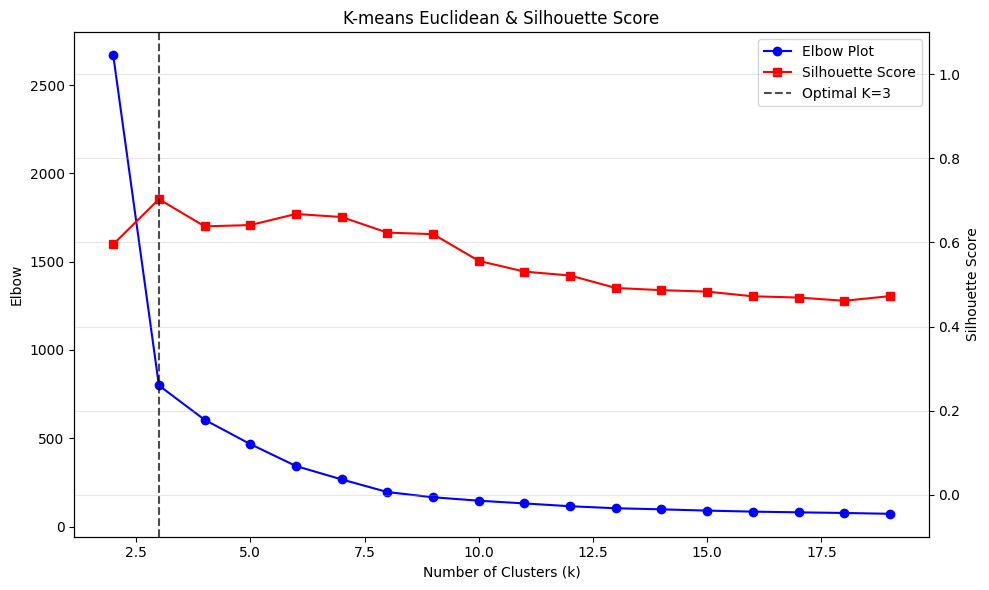

In [8]:
# Plotting the data
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Elbow')
line1, = ax1.plot(K_range_e, inertia_e, marker='o', color='blue', label='Elbow Plot')
ax1.tick_params(axis='y')

ax2 = ax1.twinx() 
ax2.set_ylabel('Silhouette Score')
line2, = ax2.plot(K_range_e, s_scores_e, marker='s', color='red', label='Silhouette Score')
ax2.tick_params(axis='y')
ax2.set_ylim(-0.1, 1.1)

optimal_k = plt.axvline(x=3, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Optimal K=3')

lines = [line1, line2, optimal_k]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title('K-means Euclidean & Silhouette Score')
plt.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [9]:
K_range_h = range(2, 20)
inertia_h = []
s_scores_h = []

for k in K_range_h:
    kmedoids = KMedoids(n_clusters=k, metric='haversine', method='pam', random_state=42)
    kmedoids.fit(institution_radians)
    
    inertia_h.append(kmedoids.inertia_)
    s_scores_h.append(silhouette_score(institution_radians, kmedoids.labels_))
print("✅ Finished k-means haversine")

✅ Finished k-means haversine


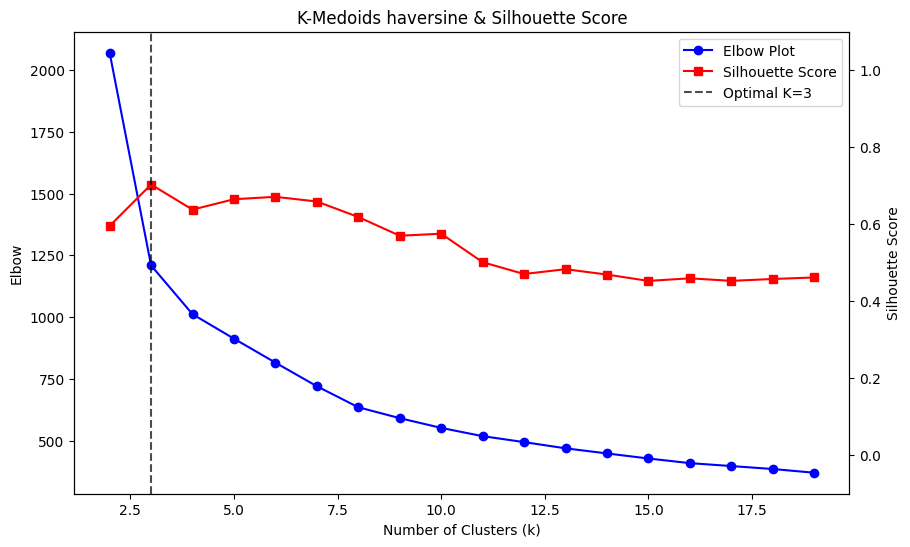

In [10]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Elbow')
line1, = ax1.plot(K_range_h, inertia_h, marker='o', color='blue', label='Elbow Plot')
ax1.tick_params(axis='y')

ax2 = ax1.twinx() 
ax2.set_ylabel('Silhouette Score')
line2, = ax2.plot(K_range_h, s_scores_h, marker='s', color='red', label='Silhouette Score')
ax2.tick_params(axis='y')
ax2.set_ylim(-0.1, 1.1)

optimal_k = plt.axvline(x=3, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Optimal K=3')

lines = [line1, line2, optimal_k]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title('K-Medoids haversine & Silhouette Score')
plt.savefig(f"kmeans-haversine.png", dpi=300)
plt.show()

After running DBSCAN, we are given 76 research hubs, which will be much more useful to track the spread of topics. There are 818 institutions that do not belong to any research hubs, but may still be researching and publishing works on machine learning topics.

The research clusters are named by the city with the most institutions within the research cluster, not the city that is at the centroid of the hub.

The centroids for each research hub a calculated by taking the mean latitude and longitude of all the institutions in the cluster.

In [64]:
# Run DBSCAN
model = HDBSCAN(min_cluster_size=10, min_samples=2, metric='haversine', cluster_selection_method='eom', copy=True)
institutions['dbscan_cluster'] = model.fit_predict(institution_radians)

# Find the hub names
hub_names = institutions[institutions['dbscan_cluster'] != -1].groupby('dbscan_cluster')['city'].agg(lambda x: x.value_counts().index[0])

num_hubs = len(institutions[institutions['dbscan_cluster'] != -1]['dbscan_cluster'].unique())
noise_count = len(institutions[institutions['dbscan_cluster'] == -1])
print(f"Found {num_hubs} dense research hubs and {noise_count} noise institutions")

# Find the centroids
hub_centroids = institutions.groupby('dbscan_cluster')[['latitude', 'longitude']].mean().reset_index()

Found 168 dense research hubs and 783 noise institutions


## Counting number of works per research hub by year
1) Count how many works each institution published each year for a topic.
2) Merge the results with the research hub data and group by research hub. 
3) Save each year and its counts in a dictionary to easily access later.

In [65]:
def get_year_counts(topic_id):
    all_years_data = []
    
    for year in range(2010, 2020):
        yearly_query = f"""
            SELECT 
                w.institution_id, 
                count(distinct w.work_id) as num_works,
                avg(w.cited_by_count) as avg_cited,
                avg(w.num_authors) as avg_authors
            FROM works_topics t
            JOIN works w ON w.work_id = t.work_id
            WHERE w.publication_year = {year} AND t.topic_id = {topic_id}
            GROUP BY w.institution_id
            ORDER BY num_works DESC
        """
        
        # Get SQL results
        results = con.execute(yearly_query).df()
        if len(results) != 0:
            # Merge with cluster map
            merged = results.merge(institutions[['institution_id', 'dbscan_cluster']], on='institution_id')
            merged['total_citations'] = merged['avg_cited'] * merged['num_works']
            merged['total_authors'] = merged['avg_authors'] * merged['num_works']
            # Group by hub and get the sum or works, avg cited_by and avg authors
            counts = merged.groupby('dbscan_cluster').agg({
                'num_works': 'sum',
                'total_citations': 'sum',
                'total_authors': 'sum'
            }).reset_index()
            counts['avg_cited'] = counts['total_citations'] / counts['num_works']
            counts['avg_authors'] = counts['total_authors'] / counts['num_works']
            counts = counts[['dbscan_cluster', 'num_works', 'avg_cited', 'avg_authors']]
            sorted = counts.sort_values(by='num_works', ascending=False)
            data_for_year = (year, sorted)
            all_years_data.append(data_for_year)
    return all_years_data

## Finding the weighted center for the topic for each year
To see how the topic spreads over the years, we use Spatio-Temporal Centroid Tracking to calculate the weighted center of all the research hubs based on the number of works each hub published that year. We loop through the entire decade and calculate the distance the weighted center moved from the previous year.

In [66]:
def calculate_research_topic_center(year_counts_df):
    # Merge the hub counts with their geographic centers
    geo_data = year_counts_df.merge(hub_centroids, on='dbscan_cluster')
    # Calculate the weighted average latitude and longitude
    weights = geo_data['num_works']
    avg_lat = np.average(geo_data['latitude'], weights=weights)
    avg_lon = np.average(geo_data['longitude'], weights=weights)
    return avg_lat, avg_lon

In [67]:
def plot_yearly_difference(topic_df):
    # Filter out the first year since the distance is 0
    plot_data = topic_df.iloc[1:]
    plt.figure(figsize=(12, 6))
    
    # Plot the distance jumps
    plt.plot(plot_data['year'], plot_data['distance'], 
             marker='o', linestyle='-', color='#2c3e50', linewidth=2, markersize=8)
    
    # Professional formatting for your report
    plt.title(f'{machine_learning_topics[topic_id]}: Annual distance of Research Center', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Jump Distance (km)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(plot_data['year'])
    plt.show()

In [68]:
def calc_center_diff_from_prev_year(prev_year_center, curr_year_center, year, first):
    year_row = {}
    year_row['year'] = year
    year_row['latitude'] = curr_year_center[0]
    year_row['longitude'] = curr_year_center[1]
    if first:
        year_row['distance'] = 0
    else:
        year_row['distance'] = geodesic(curr_year_center, prev_year_center).km
    return year_row
    
    

## Putting it all together
For each machine learning topic:
1) Get the counts of works published by each research hub within the decade
2) Calculate the weighted centers for each year and calulate the distance from the previous year
3) Plot the distances

Also creating a master dict that for each year creates a list of the topics with the following stats:
* The weighted center of the topic
* The number of research hubs that published works on the topic
* The total number of works published for the topic

In [69]:
class YearStats:
    def __init__(self, id, lat, long, hubs, works, cited, authors):
        self.id = id
        self.weighted_center_lat = lat
        self.weighted_center_long = long
        self.num_hubs = hubs
        self.total_num_works = works
        self.avg_cited_by = cited
        self.avg_authors = authors

    def display_stats(self):
        return f"\t{machine_learning_topics[self.id]} -  num research hubs: {self.num_hubs} | num works: {self.total_num_works} | AVG authors: {self.avg_authors:.2f} |  AVG cited_by: {self.avg_cited_by:.2f}"
        

In [85]:
def get_top_three_hubs(year_df):
    df_with_names = year_df.merge(hub_names, on='dbscan_cluster')
    top_three = df_with_names['city'].head(3).tolist()
    return ", ".join(top_three)




Face and Expression Recognition
2010 - 576 works in 117 hubs. Top 3: Beijing, Singapore, New York
2011 - 678 works in 127 hubs. Top 3: Beijing, Paris, Singapore
2012 - 646 works in 119 hubs. Top 3: Beijing, Singapore, Hong Kong
2013 - 596 works in 114 hubs. Top 3: Beijing, Singapore, Zurich
2014 - 572 works in 118 hubs. Top 3: Beijing, Singapore, Nanjing
2015 - 721 works in 122 hubs. Top 3: Beijing, Canberra, Nanjing
2016 - 647 works in 115 hubs. Top 3: Beijing, Nanjing, Singapore
2017 - 786 works in 124 hubs. Top 3: Beijing, Xi'an, Singapore
2018 - 619 works in 108 hubs. Top 3: Beijing, Xi'an, Chengdu
2019 - 602 works in 112 hubs. Top 3: Beijing, Xi'an, Chengdu


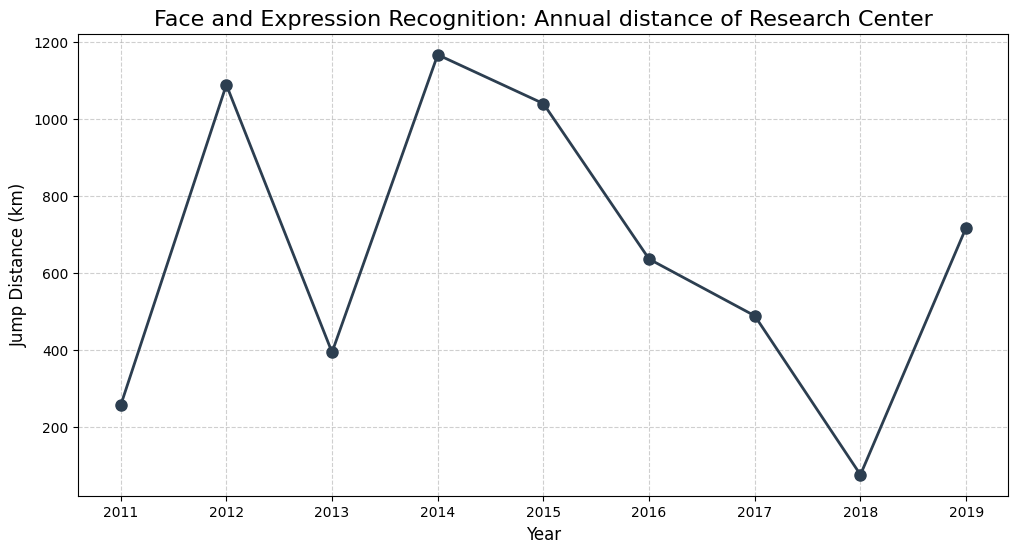




Data Mining Algorithms and Applications
2010 - 342 works in 104 hubs. Top 3: Beijing, Paris, Kaohsiung
2011 - 327 works in 104 hubs. Top 3: Beijing, Paris, Hong Kong
2012 - 341 works in 99 hubs. Top 3: Beijing, Brussels, Kaohsiung
2013 - 274 works in 103 hubs. Top 3: Beijing, Paris, Brussels
2014 - 288 works in 98 hubs. Top 3: Beijing, Chengdu, Tehran
2015 - 270 works in 99 hubs. Top 3: Beijing, New York, Berlin
2016 - 263 works in 88 hubs. Top 3: Beijing, Harbin, Chengdu
2017 - 225 works in 85 hubs. Top 3: Beijing, Chengdu, Sydney
2018 - 213 works in 80 hubs. Top 3: Beijing, Jakarta, Chengdu
2019 - 189 works in 70 hubs. Top 3: Beijing, Ho Chi Minh City, Harbin


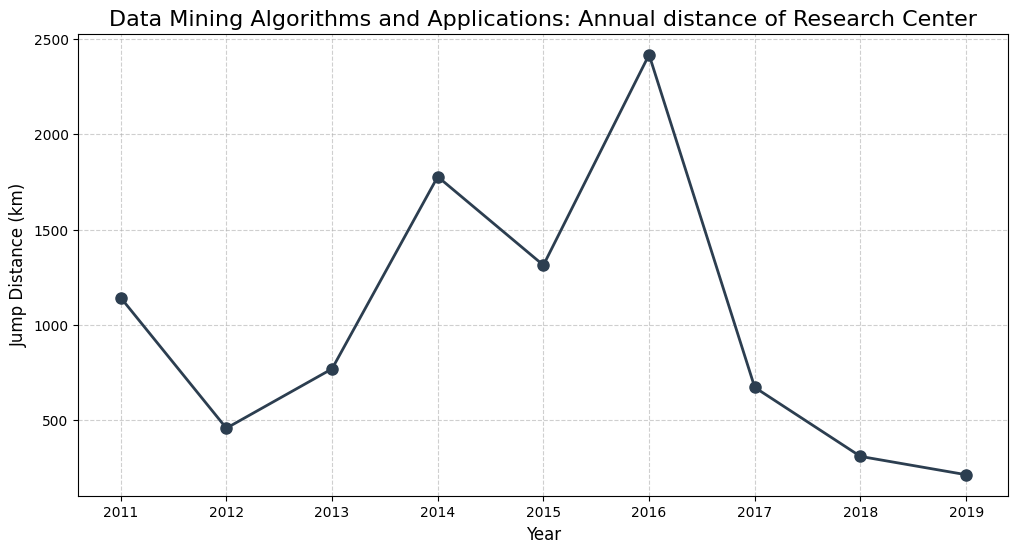




Quantum Computing Algorithms and Architecture
2010 - 569 works in 95 hubs. Top 3: Beijing, Tokyo, Paris
2011 - 589 works in 90 hubs. Top 3: Beijing, Singapore, Toronto
2012 - 709 works in 99 hubs. Top 3: Paris, Beijing, New York
2013 - 646 works in 112 hubs. Top 3: Beijing, Paris, Barcelona
2014 - 710 works in 109 hubs. Top 3: Beijing, Singapore, Toronto
2015 - 682 works in 105 hubs. Top 3: Canberra, Paris, Beijing
2016 - 695 works in 104 hubs. Top 3: Canberra, Beijing, Barcelona
2017 - 775 works in 107 hubs. Top 3: Beijing, Leiden, Canberra
2018 - 811 works in 109 hubs. Top 3: Beijing, Zurich, Leiden
2019 - 918 works in 106 hubs. Top 3: Beijing, Washington, New York


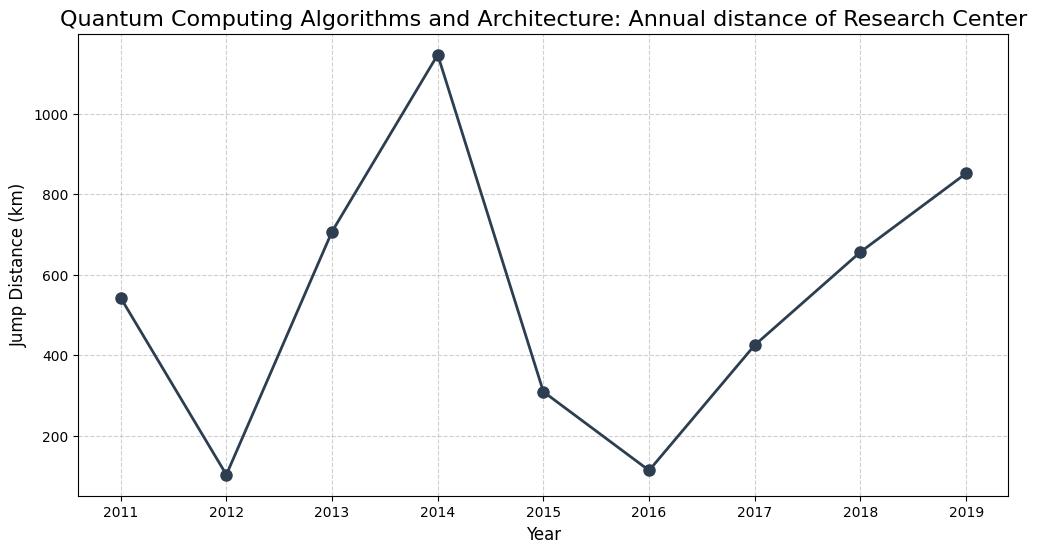




Image Retrieval and Classification Techniques
2010 - 625 works in 121 hubs. Top 3: Beijing, Paris, New York
2011 - 612 works in 127 hubs. Top 3: Beijing, Zurich, Paris
2012 - 591 works in 123 hubs. Top 3: Paris, Beijing, New York
2013 - 555 works in 124 hubs. Top 3: Beijing, Paris, Zurich
2014 - 564 works in 125 hubs. Top 3: Beijing, Singapore, Zurich
2015 - 540 works in 118 hubs. Top 3: Beijing, Paris, Singapore
2016 - 563 works in 114 hubs. Top 3: Beijing, Paris, Singapore
2017 - 490 works in 101 hubs. Top 3: Beijing, Wuhan, London
2018 - 355 works in 91 hubs. Top 3: Beijing, Wuhan, Xi'an
2019 - 369 works in 82 hubs. Top 3: Beijing, Wuhan, Xi'an


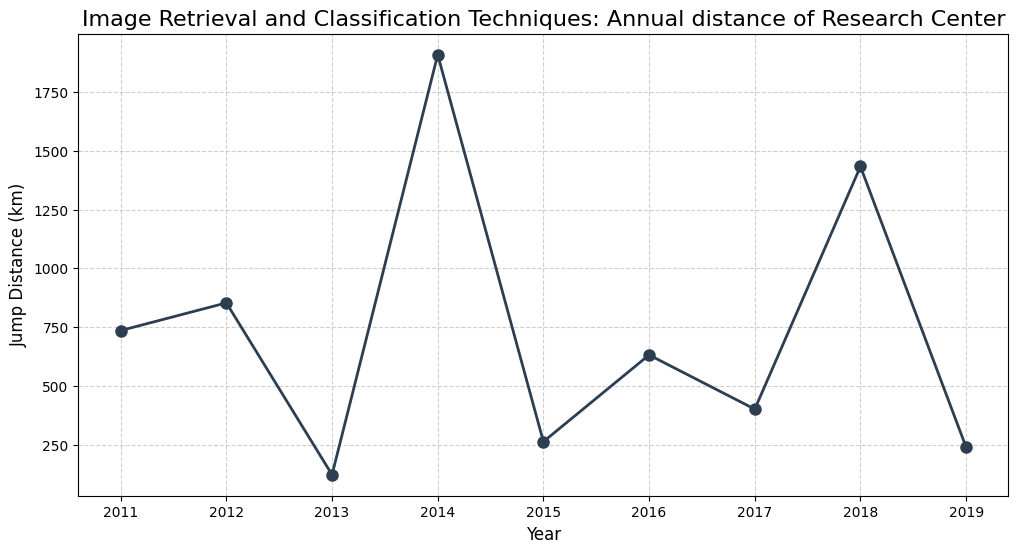




Adversarial Robustness in Machine Learning
2010 - 28 works in 16 hubs. Top 3: Seattle, Mountain View, Chicago
2011 - 27 works in 17 hubs. Top 3: Zurich, Washington, Houston
2012 - 35 works in 20 hubs. Top 3: Cambridge, Amman, Washington
2013 - 51 works in 25 hubs. Top 3: Paris, New York, Zurich
2014 - 54 works in 27 hubs. Top 3: New York, Mountain View, Munich
2015 - 106 works in 41 hubs. Top 3: Mountain View, London, Milan
2016 - 213 works in 54 hubs. Top 3: Mountain View, New York, Berkeley
2017 - 384 works in 76 hubs. Top 3: Mountain View, New York, Berkeley
2018 - 680 works in 96 hubs. Top 3: Mountain View, Cambridge, New York
2019 - 849 works in 117 hubs. Top 3: Beijing, Mountain View, Zurich


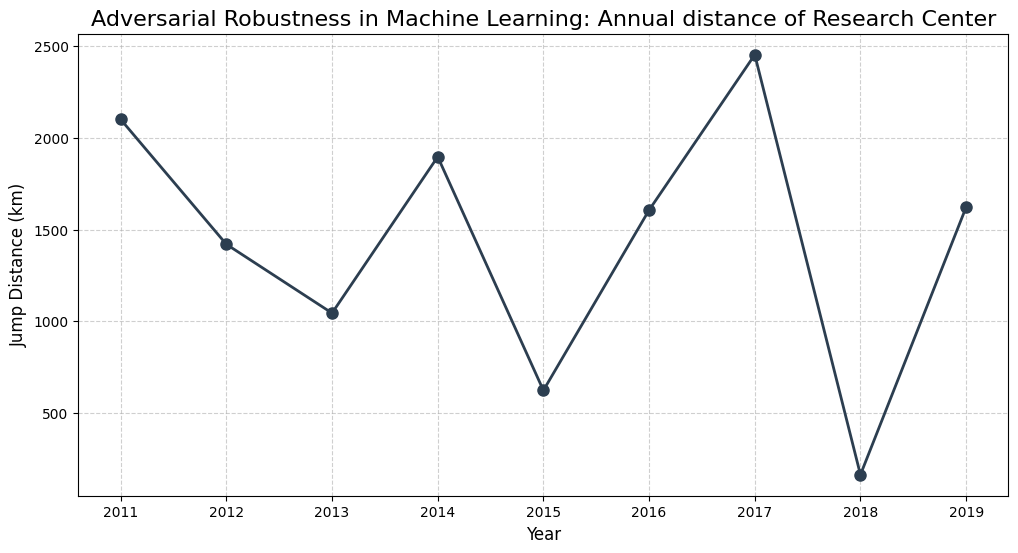




Multimodal Machine Learning Applications
2010 - 107 works in 43 hubs. Top 3: Pittsburgh, Beijing, Edinburgh
2011 - 122 works in 41 hubs. Top 3: Beijing, Zurich, Mountain View
2012 - 102 works in 47 hubs. Top 3: Singapore, Zurich, Beijing
2013 - 199 works in 62 hubs. Top 3: Paris, Berkeley, Palo Alto
2014 - 263 works in 64 hubs. Top 3: Beijing, Paris, Seattle
2015 - 420 works in 79 hubs. Top 3: Beijing, Mountain View, Palo Alto
2016 - 623 works in 98 hubs. Top 3: Beijing, Mountain View, Paris
2017 - 931 works in 103 hubs. Top 3: Beijing, Mountain View, Palo Alto
2018 - 1101 works in 117 hubs. Top 3: Beijing, Mountain View, Pittsburgh
2019 - 1363 works in 118 hubs. Top 3: Beijing, Mountain View, Palo Alto


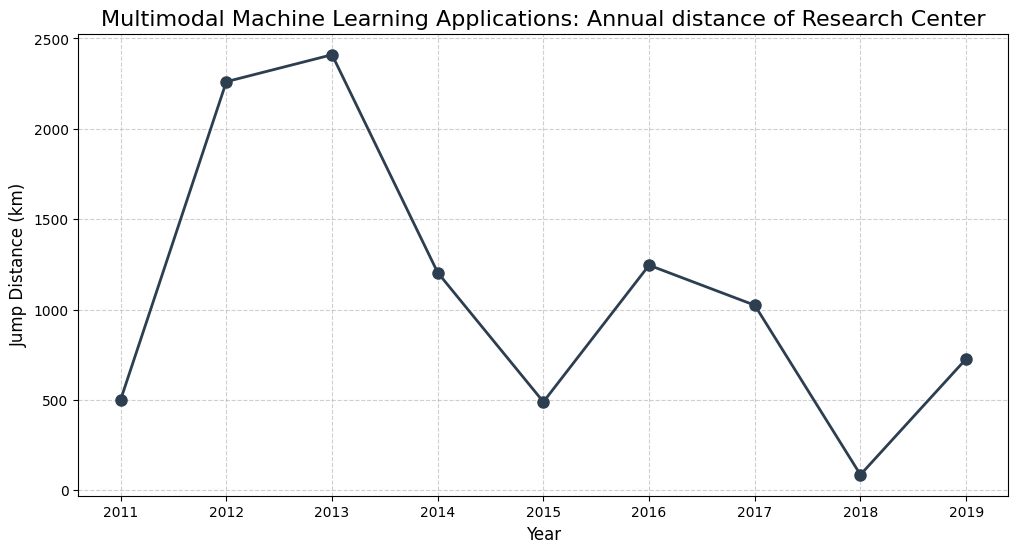




Machine Learning and Algorithms
2010 - 301 works in 81 hubs. Top 3: New York, Mountain View, Cambridge
2011 - 304 works in 74 hubs. Top 3: Seattle, Amman, New York
2012 - 284 works in 71 hubs. Top 3: New York, Seattle, Paris
2013 - 330 works in 86 hubs. Top 3: Zurich, New York, Palo Alto
2014 - 240 works in 68 hubs. Top 3: Seattle, Cambridge, Paris
2015 - 303 works in 72 hubs. Top 3: Mountain View, New York, Seattle
2016 - 235 works in 71 hubs. Top 3: Mountain View, Zurich, Beijing
2017 - 283 works in 74 hubs. Top 3: Mountain View, New York, Palo Alto
2018 - 258 works in 76 hubs. Top 3: Palo Alto, New York, Paris
2019 - 262 works in 73 hubs. Top 3: Mountain View, Cambridge, Los Angeles


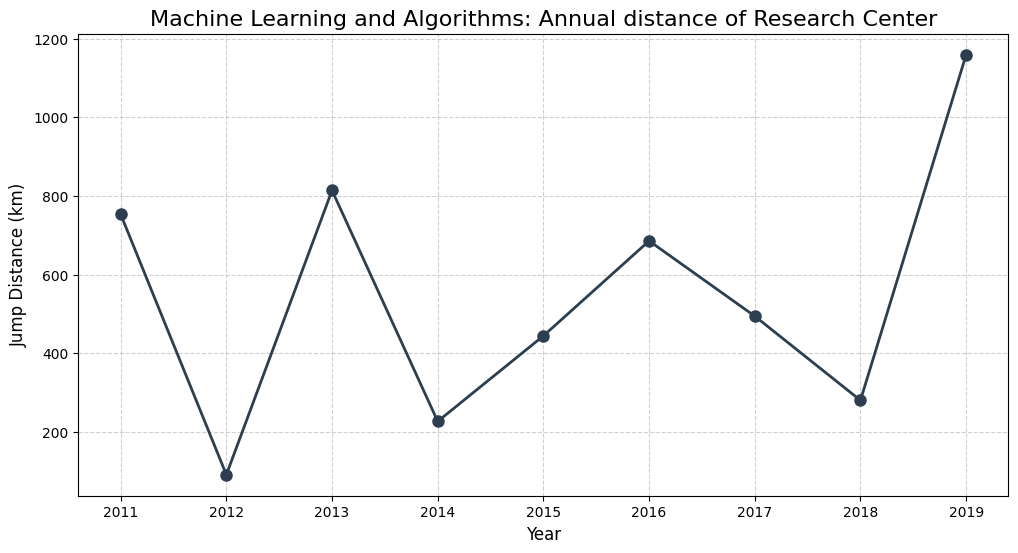




Machine Learning and Data Classification
2010 - 194 works in 73 hubs. Top 3: New York, Canberra, Beijing
2011 - 206 works in 81 hubs. Top 3: Seville, Seattle, Nanjing
2012 - 191 works in 74 hubs. Top 3: Singapore, Seville, Porto
2013 - 227 works in 76 hubs. Top 3: Rio de Janeiro, New York, Seville
2014 - 227 works in 78 hubs. Top 3: Canberra, New York, Beijing
2015 - 326 works in 97 hubs. Top 3: Paris, Beijing, Canberra
2016 - 348 works in 104 hubs. Top 3: London, Porto, Seattle
2017 - 403 works in 99 hubs. Top 3: Mountain View, Beijing, Palo Alto
2018 - 431 works in 109 hubs. Top 3: Mountain View, Pittsburgh, Rio de Janeiro
2019 - 520 works in 131 hubs. Top 3: Mountain View, Beijing, London


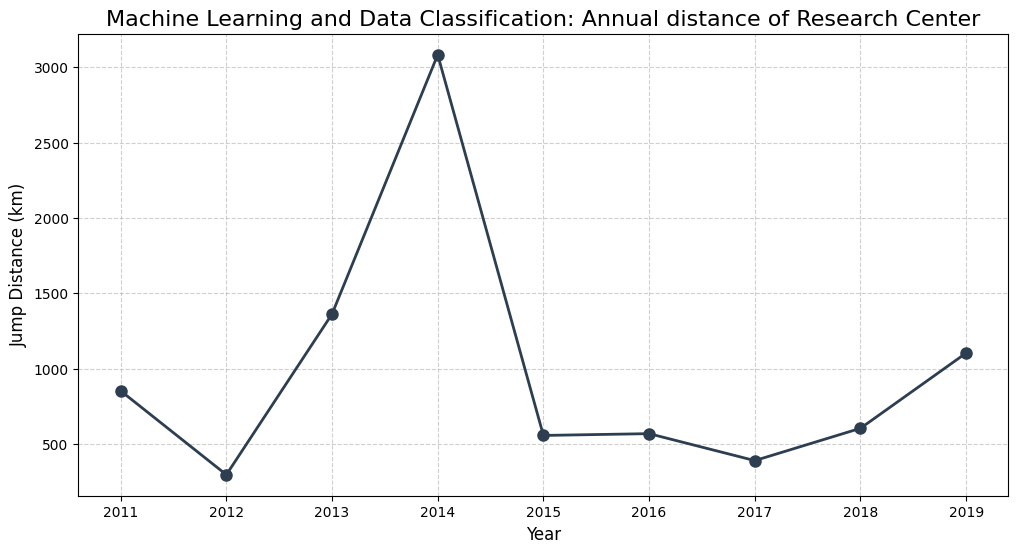




Machine Learning and ELM
2010 - 76 works in 32 hubs. Top 3: Singapore, Hong Kong, Canberra
2011 - 124 works in 48 hubs. Top 3: Singapore, Paris, Shanghai
2012 - 135 works in 55 hubs. Top 3: Singapore, Beijing, Hangzhou
2013 - 191 works in 57 hubs. Top 3: Beijing, Singapore, Dalian
2014 - 182 works in 67 hubs. Top 3: Beijing, Singapore, Hong Kong
2015 - 274 works in 81 hubs. Top 3: Beijing, Singapore, Nanjing
2016 - 260 works in 76 hubs. Top 3: Beijing, Singapore, Dalian
2017 - 389 works in 96 hubs. Top 3: Beijing, Dalian, Shanghai
2018 - 404 works in 88 hubs. Top 3: Beijing, Paris, New York
2019 - 472 works in 99 hubs. Top 3: Beijing, Nanjing, Jinan


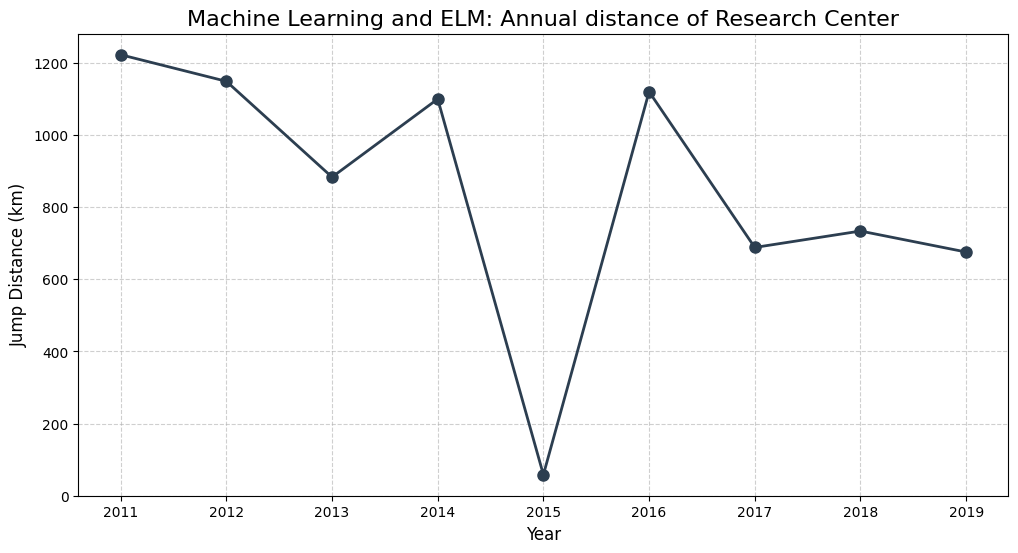




Machine Learning in Healthcare
2010 - 42 works in 25 hubs. Top 3: Taipei, Houston, Washington
2011 - 61 works in 32 hubs. Top 3: Seattle, New York, Bethesda
2012 - 64 works in 29 hubs. Top 3: Cambridge, New York, Manchester
2013 - 95 works in 38 hubs. Top 3: New York, London, Pittsburgh
2014 - 126 works in 54 hubs. Top 3: Paris, New York, London
2015 - 154 works in 50 hubs. Top 3: Boston, New York, Cambridge
2016 - 217 works in 62 hubs. Top 3: New York, London, Zurich
2017 - 244 works in 74 hubs. Top 3: London, New York, Cambridge
2018 - 385 works in 85 hubs. Top 3: New York, London, Toronto
2019 - 626 works in 114 hubs. Top 3: London, Toronto, Durham


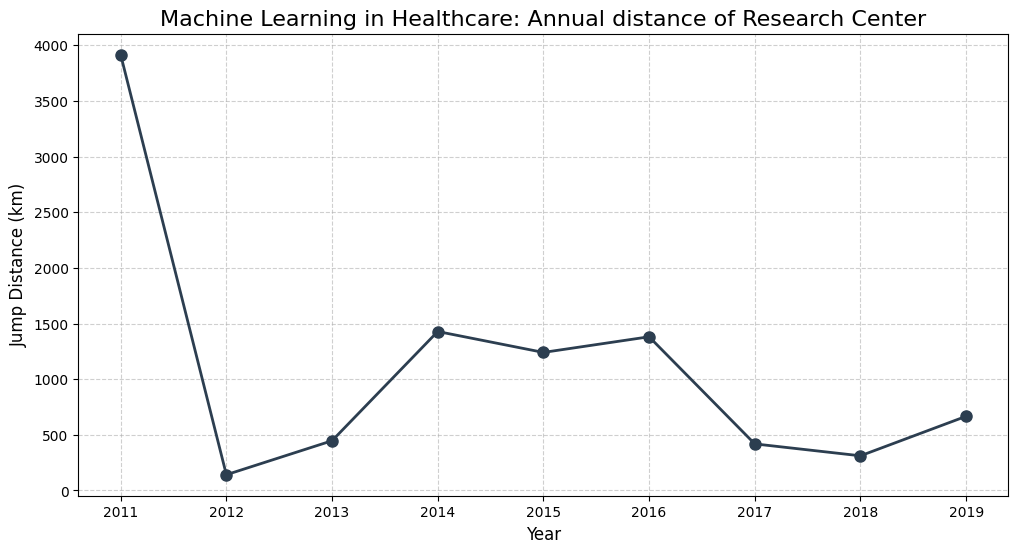

In [86]:
# Create a master dict that store all the topic centers by year
all_topics_all_year_centers = {}
for topic_id in machine_learning_topics:
    print("\n\n")
    print("=" * 50)
    print(machine_learning_topics[topic_id])
    print("=" * 50)
    all_years_data = get_year_counts(topic_id)
    annual_distance_data = []
    previous_year = (0,0)
    for index, year_tupple in enumerate(all_years_data):
        year = year_tupple[0]
        year_df = year_tupple[1]
        total_num_works = year_df['num_works'].sum()
        num_hubs = len(year_df['dbscan_cluster'].tolist())
       # Find the weighted center of the research
        year_weigthed_center = calculate_research_topic_center(year_tupple[1])
        # Calculate distance from last year center
        if index == 0:
            annual_distance_data.append(calc_center_diff_from_prev_year(previous_year, year_weigthed_center, year, True))
        else:
            annual_distance_data.append(calc_center_diff_from_prev_year(previous_year, year_weigthed_center, year, False))

        # Add the topic's center, num_hubs, and total_num_works to the master dict
        if year not in all_topics_all_year_centers:
            all_topics_all_year_centers[year] = []
        year_list = all_topics_all_year_centers[year]
        overall_avg_cited = year_df['avg_cited'].sum() / len(year_df['dbscan_cluster'].tolist())
        overal_avg_authors = year_df['avg_authors'].sum() / len(year_df['dbscan_cluster'].tolist())
        year_obj = YearStats(topic_id, year_weigthed_center[0], year_weigthed_center[1], num_hubs, total_num_works, overall_avg_cited, overal_avg_authors)
        top_3 = get_top_three_hubs(year_df)
        print(f"{year} - {total_num_works} works in {num_hubs} hubs. Top 3: {top_3}")
        year_list.append(year_obj)
        all_topics_all_year_centers[year] = year_list

        previous_year = year_weigthed_center
        
    # Create a dataframe for plotting
    df_yearly_centers = pd.DataFrame(annual_distance_data)
    # Plot the distances by year for the topic
    plot_yearly_difference(df_yearly_centers)

In [72]:
def plot_topics_centers_for_year(centers_map_df):
    fig, ax = plt.subplots(figsize=(15, 8))
    # Add map background
    world = gpd.read_file(geodatasets.data.naturalearth.land['url'])
    world.plot(ax=ax, color='#f0f0f0', edgecolor='#d0d0d0') 
    # Plot points
    ax.scatter(
        centers_map_df['weighted_center_long'], 
        centers_map_df['weighted_center_lat'], 
        c=centers_map_df['color'],
        s=centers_map_df['num_hubs'] * 25,
        alpha=0.8, 
        edgecolor='black', 
        linewidth=0.7,
        zorder=3
    )
    
    # Add Legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label=f'{machine_learning_topics[tid]}',
               markerfacecolor=topic_colors[tid], markersize=10)
        for tid in sorted(centers_map_df['id'].unique())
    ]
    ax.legend(handles=legend_elements, loc='lower left', title="Topics", frameon=True)

    plt.title(f"Topic weighted centers - {year}", fontsize=16, pad=20)
    plt.axis('off')
    plt.tight_layout()
    
    plt.savefig(f"map_{year}.png", dpi=300)
    plt.show()

In 2010:
	Face and Expression Recognition -  num research hubs: 117 | num works: 576 | AVG authors: 3.10 |  AVG cited_by: 241.94
	Data Mining Algorithms and Applications -  num research hubs: 104 | num works: 342 | AVG authors: 3.17 |  AVG cited_by: 161.79
	Quantum Computing Algorithms and Architecture -  num research hubs: 95 | num works: 569 | AVG authors: 4.08 |  AVG cited_by: 160.72
	Image Retrieval and Classification Techniques -  num research hubs: 121 | num works: 625 | AVG authors: 3.30 |  AVG cited_by: 255.24
	Adversarial Robustness in Machine Learning -  num research hubs: 16 | num works: 28 | AVG authors: 2.84 |  AVG cited_by: 122.05
	Multimodal Machine Learning Applications -  num research hubs: 43 | num works: 107 | AVG authors: 3.55 |  AVG cited_by: 241.80
	Machine Learning and Algorithms -  num research hubs: 81 | num works: 301 | AVG authors: 3.07 |  AVG cited_by: 171.40
	Machine Learning and Data Classification -  num research hubs: 73 | num works: 194 | AVG authors: 3

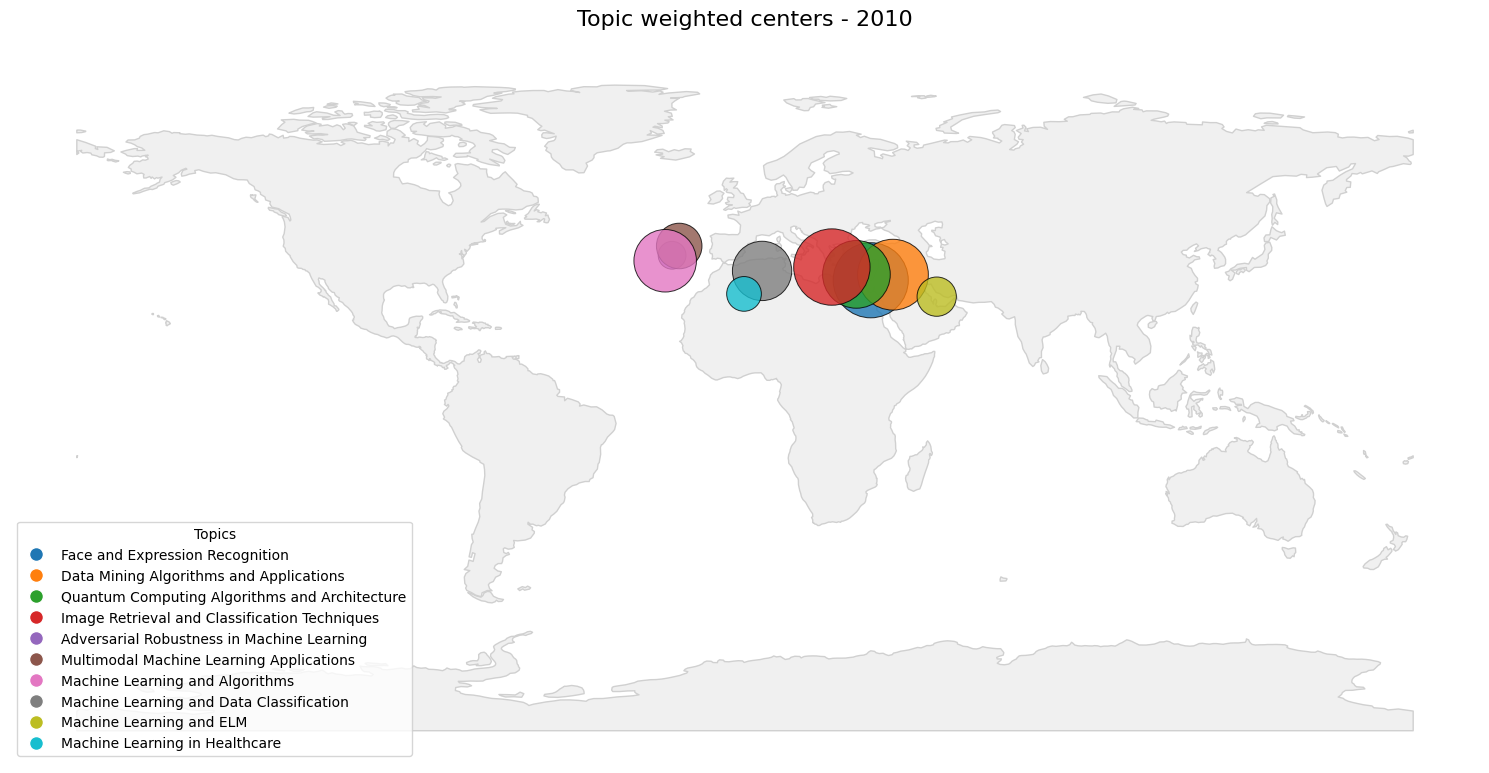

In 2011:
	Face and Expression Recognition -  num research hubs: 127 | num works: 678 | AVG authors: 3.14 |  AVG cited_by: 218.52
	Data Mining Algorithms and Applications -  num research hubs: 104 | num works: 327 | AVG authors: 3.08 |  AVG cited_by: 132.56
	Quantum Computing Algorithms and Architecture -  num research hubs: 90 | num works: 589 | AVG authors: 3.67 |  AVG cited_by: 159.22
	Image Retrieval and Classification Techniques -  num research hubs: 127 | num works: 612 | AVG authors: 3.44 |  AVG cited_by: 191.89
	Adversarial Robustness in Machine Learning -  num research hubs: 17 | num works: 27 | AVG authors: 2.89 |  AVG cited_by: 169.65
	Multimodal Machine Learning Applications -  num research hubs: 41 | num works: 122 | AVG authors: 3.70 |  AVG cited_by: 240.32
	Machine Learning and Algorithms -  num research hubs: 74 | num works: 304 | AVG authors: 3.03 |  AVG cited_by: 180.33
	Machine Learning and Data Classification -  num research hubs: 81 | num works: 206 | AVG authors: 2

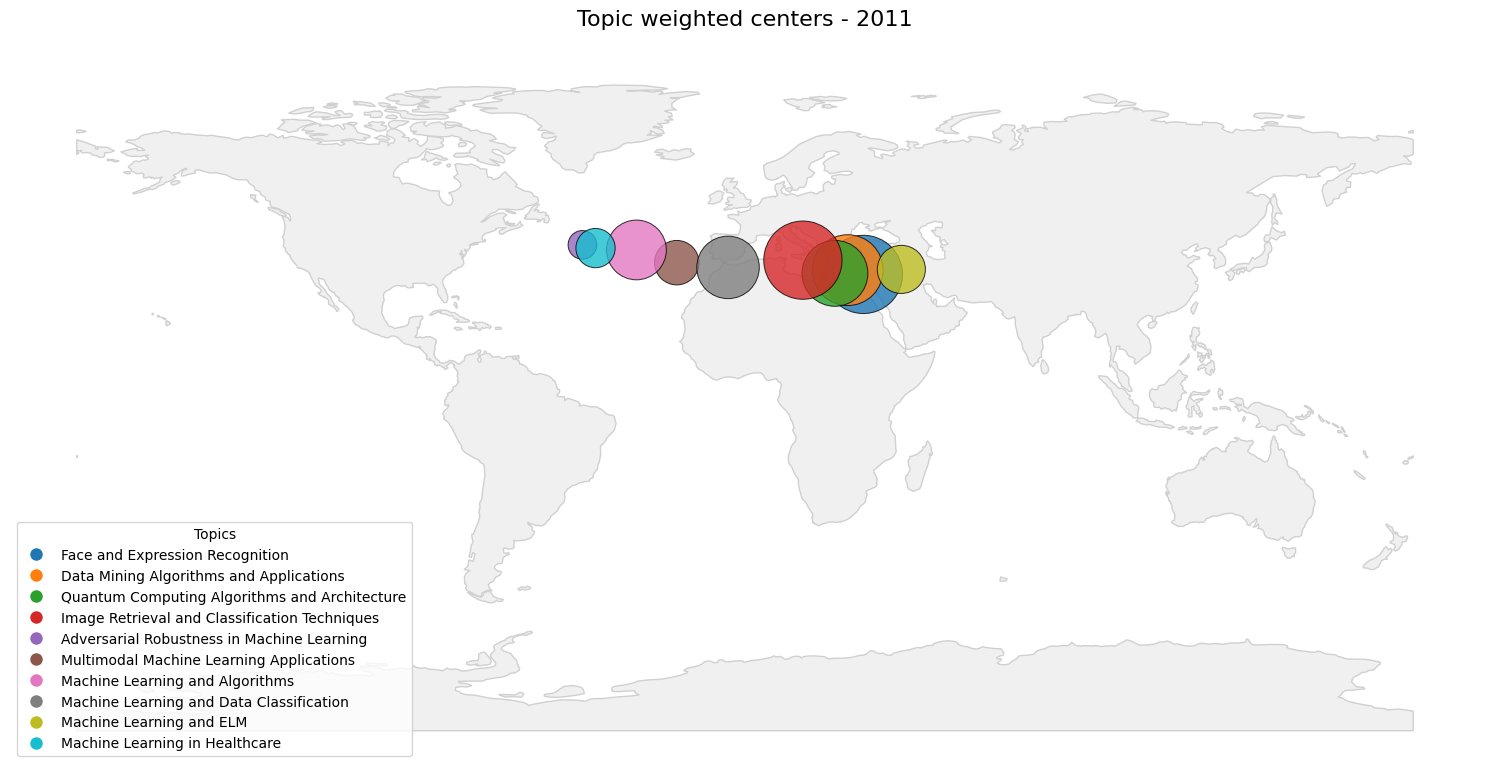

In 2012:
	Face and Expression Recognition -  num research hubs: 119 | num works: 646 | AVG authors: 3.12 |  AVG cited_by: 196.12
	Data Mining Algorithms and Applications -  num research hubs: 99 | num works: 341 | AVG authors: 3.09 |  AVG cited_by: 278.96
	Quantum Computing Algorithms and Architecture -  num research hubs: 99 | num works: 709 | AVG authors: 3.59 |  AVG cited_by: 145.22
	Image Retrieval and Classification Techniques -  num research hubs: 123 | num works: 591 | AVG authors: 3.32 |  AVG cited_by: 163.64
	Adversarial Robustness in Machine Learning -  num research hubs: 20 | num works: 35 | AVG authors: 2.90 |  AVG cited_by: 105.13
	Multimodal Machine Learning Applications -  num research hubs: 47 | num works: 102 | AVG authors: 4.07 |  AVG cited_by: 207.99
	Machine Learning and Algorithms -  num research hubs: 71 | num works: 284 | AVG authors: 3.01 |  AVG cited_by: 185.12
	Machine Learning and Data Classification -  num research hubs: 74 | num works: 191 | AVG authors: 2.

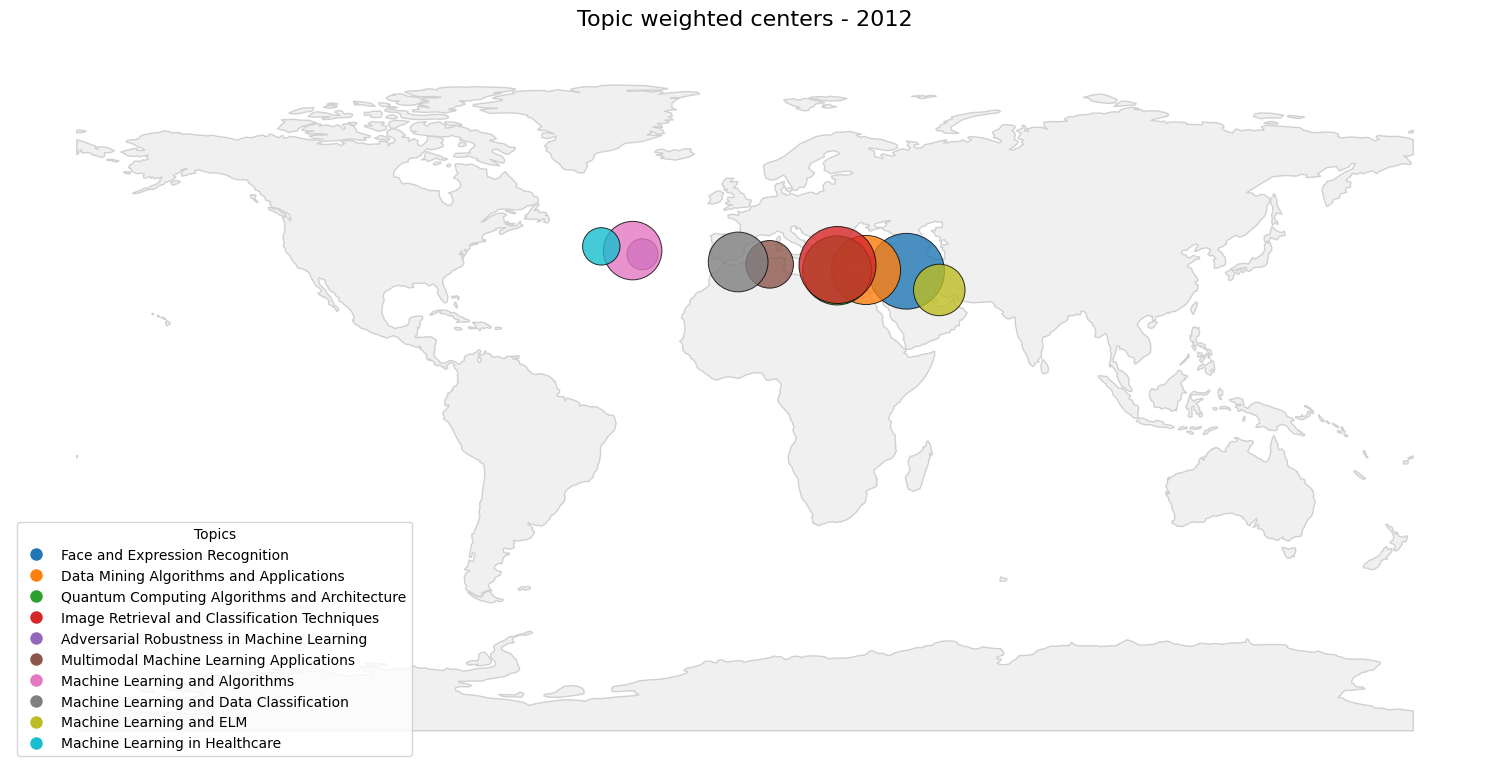

In 2013:
	Face and Expression Recognition -  num research hubs: 114 | num works: 596 | AVG authors: 3.16 |  AVG cited_by: 267.35
	Data Mining Algorithms and Applications -  num research hubs: 103 | num works: 274 | AVG authors: 3.13 |  AVG cited_by: 194.81
	Quantum Computing Algorithms and Architecture -  num research hubs: 112 | num works: 646 | AVG authors: 3.43 |  AVG cited_by: 127.91
	Image Retrieval and Classification Techniques -  num research hubs: 124 | num works: 555 | AVG authors: 3.64 |  AVG cited_by: 157.55
	Adversarial Robustness in Machine Learning -  num research hubs: 25 | num works: 51 | AVG authors: 4.05 |  AVG cited_by: 423.05
	Multimodal Machine Learning Applications -  num research hubs: 62 | num works: 199 | AVG authors: 4.12 |  AVG cited_by: 276.44
	Machine Learning and Algorithms -  num research hubs: 86 | num works: 330 | AVG authors: 3.21 |  AVG cited_by: 165.22
	Machine Learning and Data Classification -  num research hubs: 76 | num works: 227 | AVG authors: 

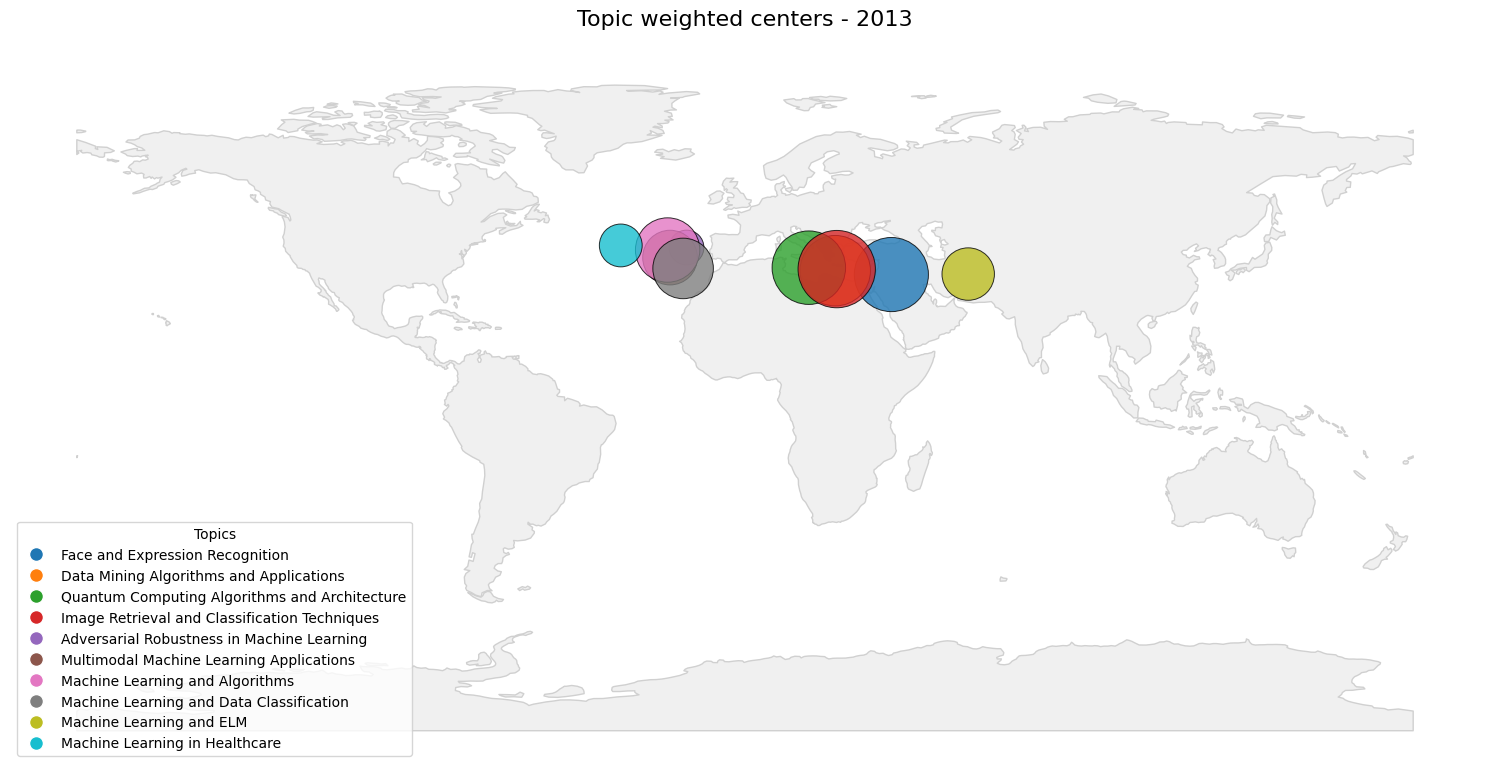

In 2014:
	Face and Expression Recognition -  num research hubs: 118 | num works: 572 | AVG authors: 3.52 |  AVG cited_by: 190.26
	Data Mining Algorithms and Applications -  num research hubs: 98 | num works: 288 | AVG authors: 3.04 |  AVG cited_by: 174.94
	Quantum Computing Algorithms and Architecture -  num research hubs: 109 | num works: 710 | AVG authors: 3.94 |  AVG cited_by: 140.19
	Image Retrieval and Classification Techniques -  num research hubs: 125 | num works: 564 | AVG authors: 3.95 |  AVG cited_by: 145.21
	Adversarial Robustness in Machine Learning -  num research hubs: 27 | num works: 54 | AVG authors: 3.54 |  AVG cited_by: 509.93
	Multimodal Machine Learning Applications -  num research hubs: 64 | num works: 263 | AVG authors: 4.10 |  AVG cited_by: 501.95
	Machine Learning and Algorithms -  num research hubs: 68 | num works: 240 | AVG authors: 3.26 |  AVG cited_by: 510.47
	Machine Learning and Data Classification -  num research hubs: 78 | num works: 227 | AVG authors: 3

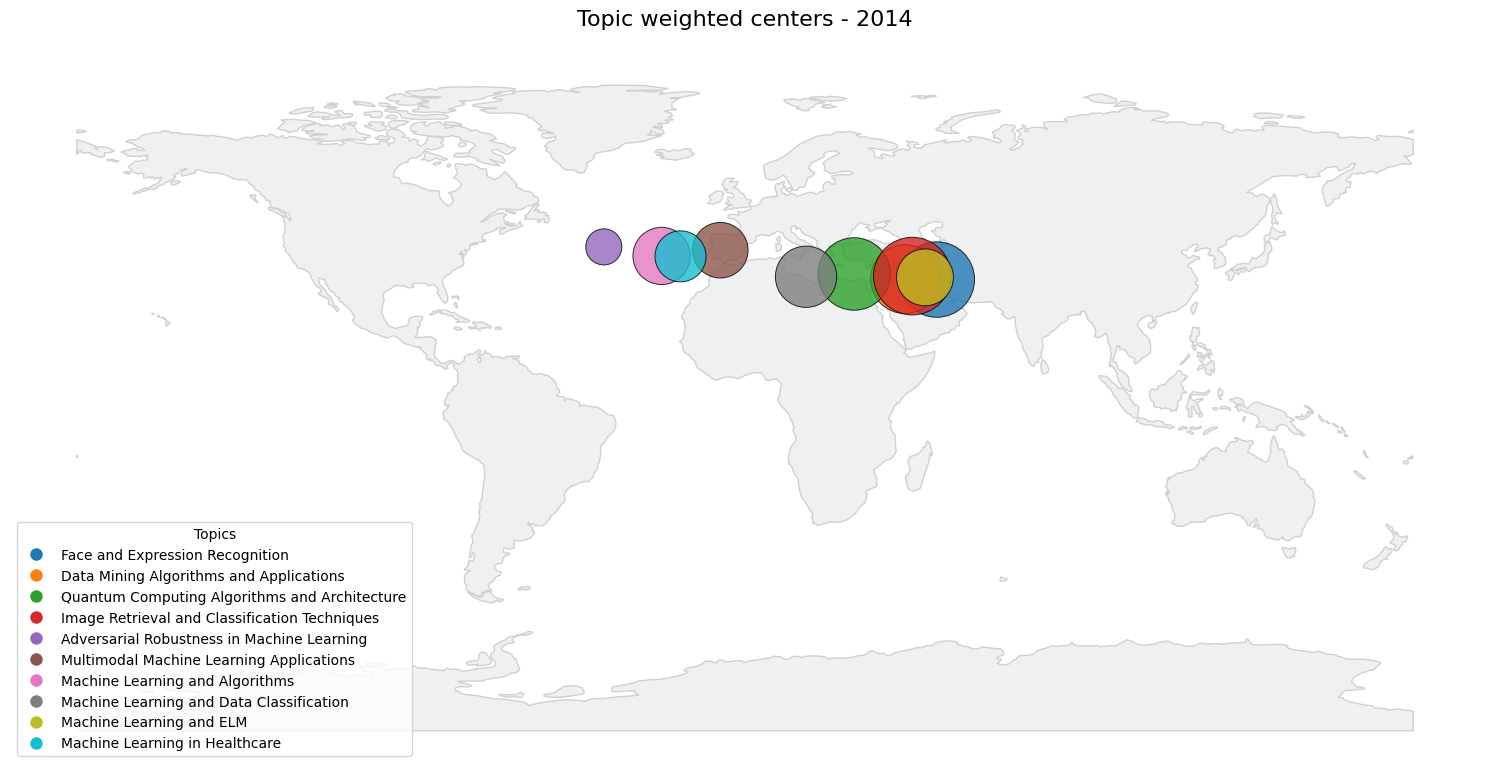

In 2015:
	Face and Expression Recognition -  num research hubs: 122 | num works: 721 | AVG authors: 3.56 |  AVG cited_by: 195.41
	Data Mining Algorithms and Applications -  num research hubs: 99 | num works: 270 | AVG authors: 3.20 |  AVG cited_by: 152.60
	Quantum Computing Algorithms and Architecture -  num research hubs: 105 | num works: 682 | AVG authors: 4.29 |  AVG cited_by: 137.13
	Image Retrieval and Classification Techniques -  num research hubs: 118 | num works: 540 | AVG authors: 3.73 |  AVG cited_by: 205.33
	Adversarial Robustness in Machine Learning -  num research hubs: 41 | num works: 106 | AVG authors: 3.62 |  AVG cited_by: 460.48
	Multimodal Machine Learning Applications -  num research hubs: 79 | num works: 420 | AVG authors: 4.04 |  AVG cited_by: 485.53
	Machine Learning and Algorithms -  num research hubs: 72 | num works: 303 | AVG authors: 3.34 |  AVG cited_by: 177.05
	Machine Learning and Data Classification -  num research hubs: 97 | num works: 326 | AVG authors: 

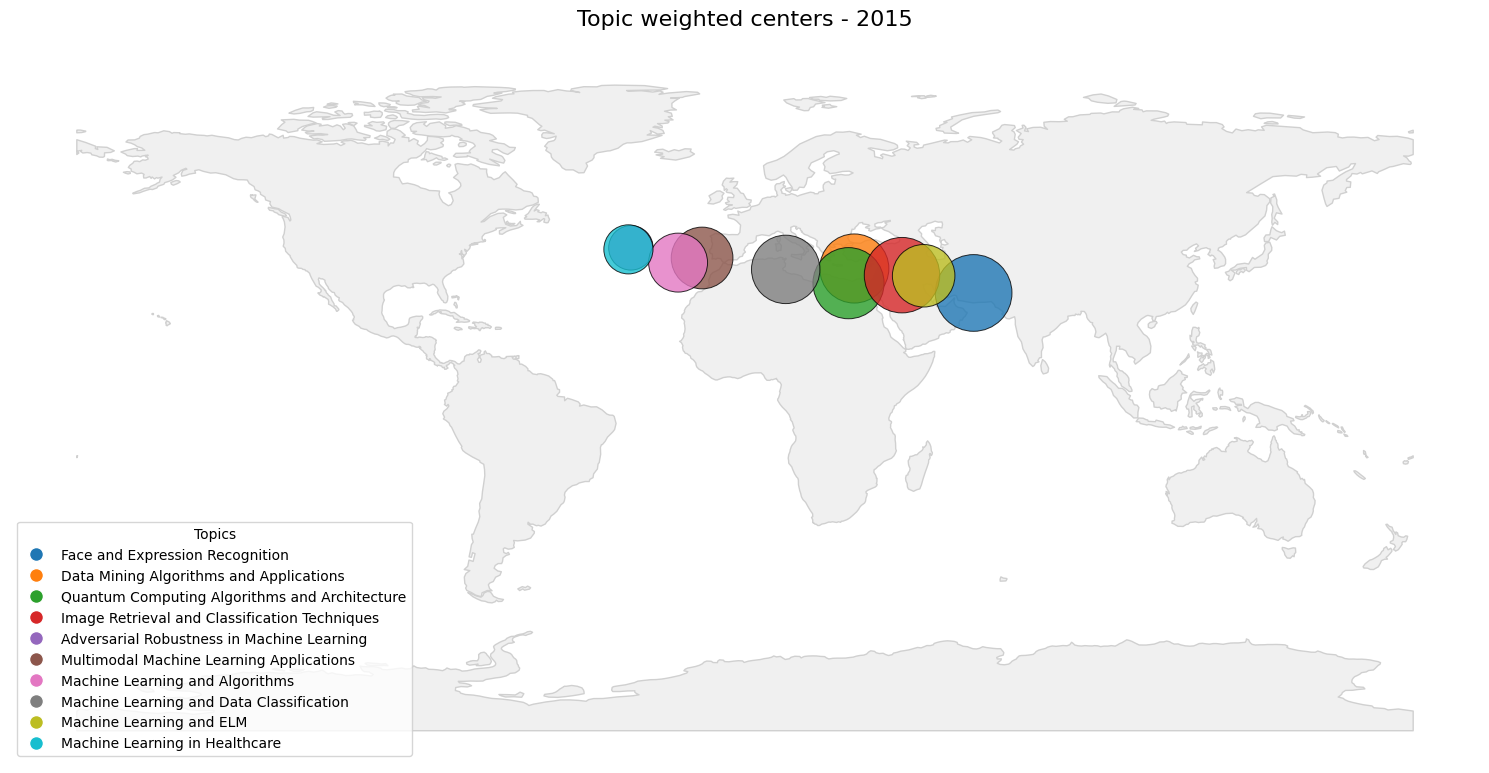

In 2016:
	Face and Expression Recognition -  num research hubs: 115 | num works: 647 | AVG authors: 3.50 |  AVG cited_by: 171.64
	Data Mining Algorithms and Applications -  num research hubs: 88 | num works: 263 | AVG authors: 3.17 |  AVG cited_by: 111.57
	Quantum Computing Algorithms and Architecture -  num research hubs: 104 | num works: 695 | AVG authors: 4.14 |  AVG cited_by: 132.87
	Image Retrieval and Classification Techniques -  num research hubs: 114 | num works: 563 | AVG authors: 3.93 |  AVG cited_by: 136.84
	Adversarial Robustness in Machine Learning -  num research hubs: 54 | num works: 213 | AVG authors: 3.72 |  AVG cited_by: 526.30
	Multimodal Machine Learning Applications -  num research hubs: 98 | num works: 623 | AVG authors: 4.14 |  AVG cited_by: 245.34
	Machine Learning and Algorithms -  num research hubs: 71 | num works: 235 | AVG authors: 3.45 |  AVG cited_by: 167.65
	Machine Learning and Data Classification -  num research hubs: 104 | num works: 348 | AVG authors:

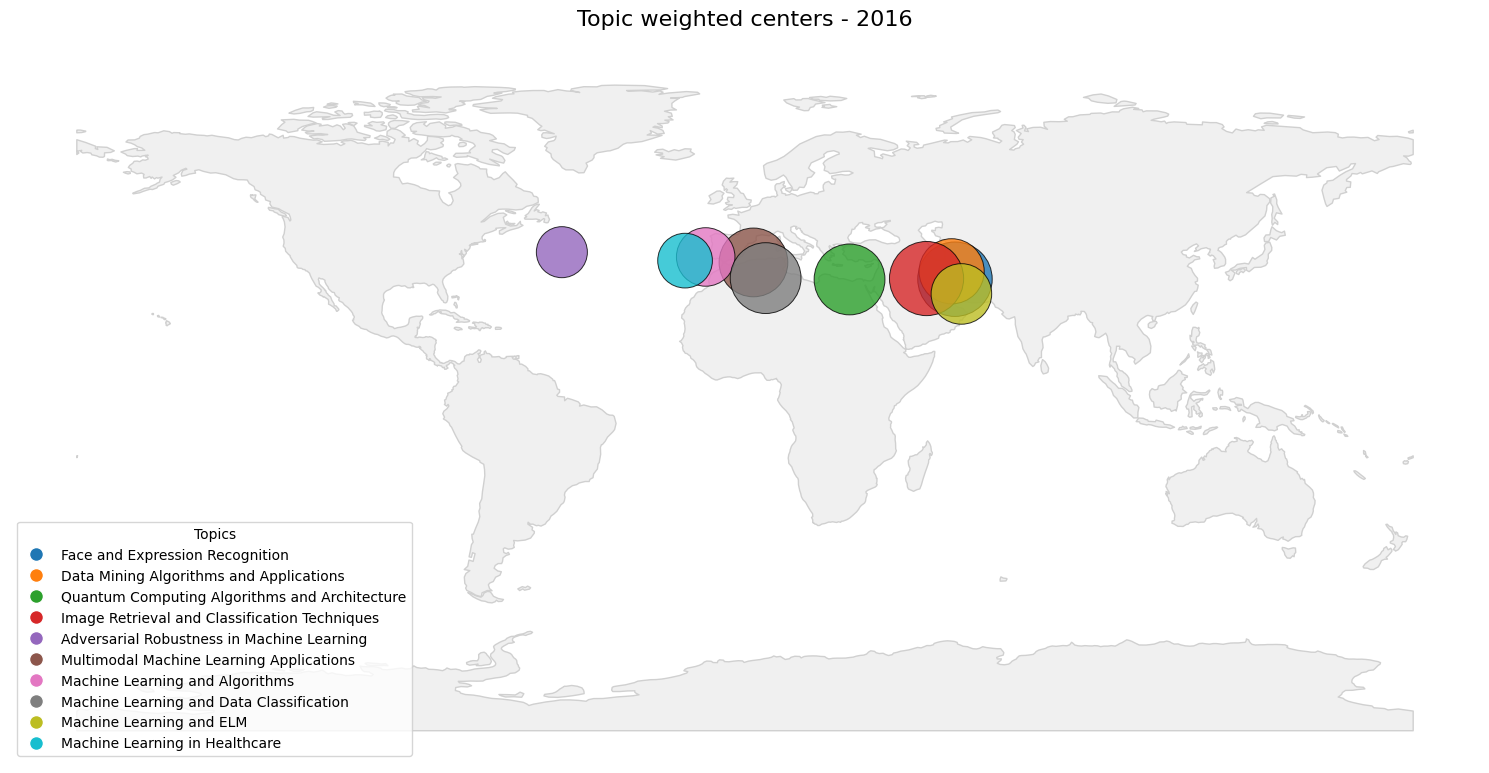

In 2017:
	Face and Expression Recognition -  num research hubs: 124 | num works: 786 | AVG authors: 3.74 |  AVG cited_by: 156.56
	Data Mining Algorithms and Applications -  num research hubs: 85 | num works: 225 | AVG authors: 3.89 |  AVG cited_by: 168.32
	Quantum Computing Algorithms and Architecture -  num research hubs: 107 | num works: 775 | AVG authors: 4.82 |  AVG cited_by: 127.52
	Image Retrieval and Classification Techniques -  num research hubs: 101 | num works: 490 | AVG authors: 3.85 |  AVG cited_by: 230.50
	Adversarial Robustness in Machine Learning -  num research hubs: 76 | num works: 384 | AVG authors: 3.80 |  AVG cited_by: 345.10
	Multimodal Machine Learning Applications -  num research hubs: 103 | num works: 931 | AVG authors: 3.96 |  AVG cited_by: 348.75
	Machine Learning and Algorithms -  num research hubs: 74 | num works: 283 | AVG authors: 3.70 |  AVG cited_by: 159.89
	Machine Learning and Data Classification -  num research hubs: 99 | num works: 403 | AVG authors:

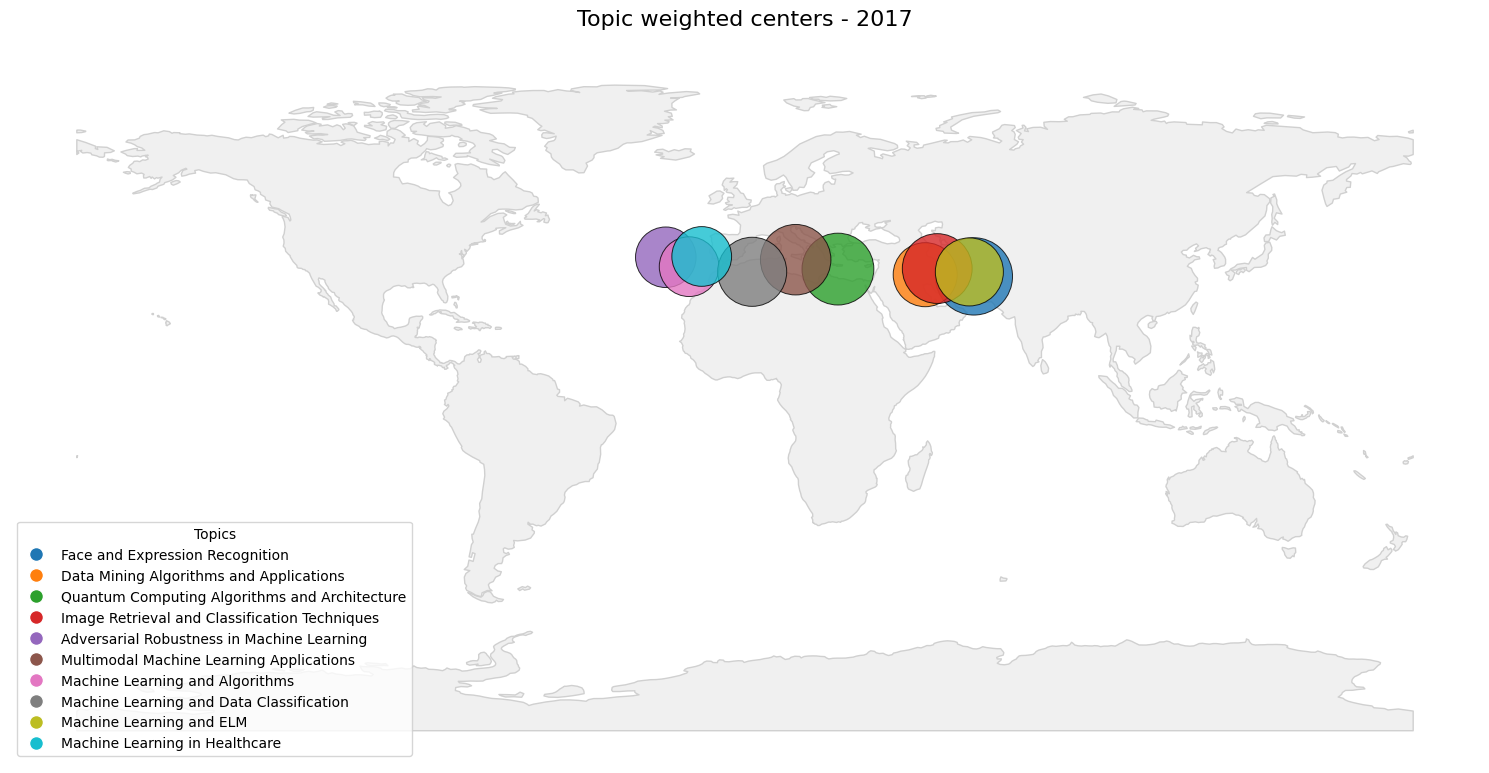

In 2018:
	Face and Expression Recognition -  num research hubs: 108 | num works: 619 | AVG authors: 3.79 |  AVG cited_by: 152.83
	Data Mining Algorithms and Applications -  num research hubs: 80 | num works: 213 | AVG authors: 3.50 |  AVG cited_by: 124.16
	Quantum Computing Algorithms and Architecture -  num research hubs: 109 | num works: 811 | AVG authors: 4.83 |  AVG cited_by: 132.14
	Image Retrieval and Classification Techniques -  num research hubs: 91 | num works: 355 | AVG authors: 4.29 |  AVG cited_by: 120.17
	Adversarial Robustness in Machine Learning -  num research hubs: 96 | num works: 680 | AVG authors: 4.06 |  AVG cited_by: 314.80
	Multimodal Machine Learning Applications -  num research hubs: 117 | num works: 1101 | AVG authors: 4.33 |  AVG cited_by: 245.60
	Machine Learning and Algorithms -  num research hubs: 76 | num works: 258 | AVG authors: 3.62 |  AVG cited_by: 141.85
	Machine Learning and Data Classification -  num research hubs: 109 | num works: 431 | AVG authors

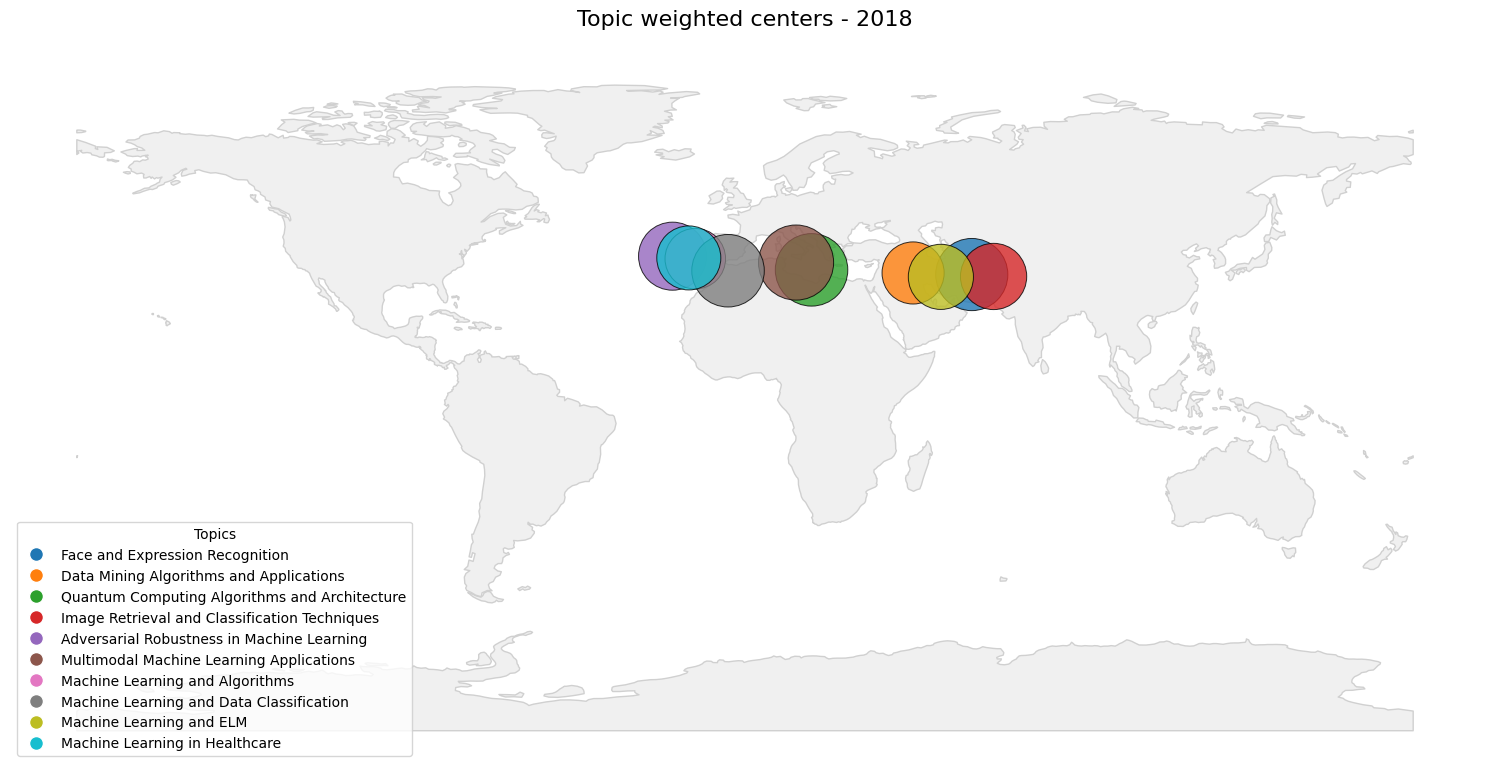

In 2019:
	Face and Expression Recognition -  num research hubs: 112 | num works: 602 | AVG authors: 3.91 |  AVG cited_by: 134.15
	Data Mining Algorithms and Applications -  num research hubs: 70 | num works: 189 | AVG authors: 3.81 |  AVG cited_by: 136.49
	Quantum Computing Algorithms and Architecture -  num research hubs: 106 | num works: 918 | AVG authors: 4.78 |  AVG cited_by: 133.79
	Image Retrieval and Classification Techniques -  num research hubs: 82 | num works: 369 | AVG authors: 4.20 |  AVG cited_by: 156.63
	Adversarial Robustness in Machine Learning -  num research hubs: 117 | num works: 849 | AVG authors: 4.20 |  AVG cited_by: 212.62
	Multimodal Machine Learning Applications -  num research hubs: 118 | num works: 1363 | AVG authors: 4.35 |  AVG cited_by: 185.36
	Machine Learning and Algorithms -  num research hubs: 73 | num works: 262 | AVG authors: 4.11 |  AVG cited_by: 135.32
	Machine Learning and Data Classification -  num research hubs: 131 | num works: 520 | AVG author

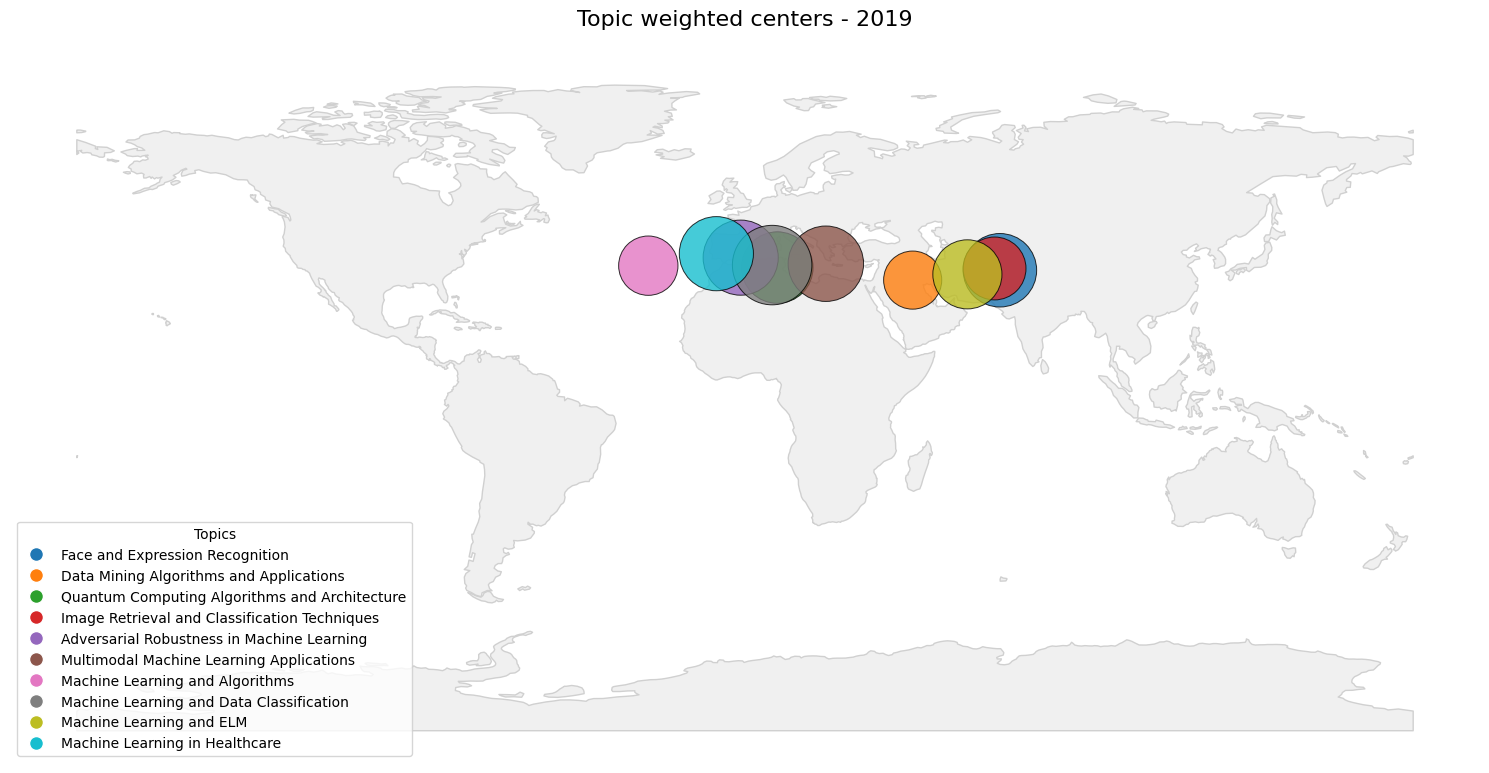

In [73]:
# Assign colors to the topics
cmap = plt.get_cmap('tab10')
topic_colors = {topic: cmap(i) for i, topic in enumerate(topic_ids)}

for year in all_topics_all_year_centers:
    topics_list = all_topics_all_year_centers[year]
    print(f"In {year}:")
    for topic in topics_list:
        print(topic.display_stats())
    # Convert the list of topic_tupples into a df
    topic_map_df = pd.DataFrame([vars(t) for t in topics_list])
    # topic_map_df = pd.DataFrame(topics_list, columns=['topic_id', 'centroid_lat', 'centroid_long', 'num_hubs', 'total_num_works', 'avg_cited_by', 'avg_authors'])
    # Add the topic colors
    topic_map_df['color'] = topic_map_df['id'].map(topic_colors)
    # Plot the topic centers
    plot_topics_centers_for_year(topic_map_df)
    

In [76]:
results = get_year_counts(10682)

for index, year_tupple in enumerate(results):
    year = year_tupple[0]
    year_df = year_tupple[1]
    df_with_names = year_df.merge(hub_names, on='dbscan_cluster')
    print(year)
    display(df_with_names.head(3))
        
    

2010


,dbscan_cluster,num_works,avg_cited,avg_authors,city
0,88,46,143.478261,3.828063,Beijing
1,34,27,153.975309,4.802469,Tokyo
2,155,22,136.212121,3.378788,Paris


2011


,dbscan_cluster,num_works,avg_cited,avg_authors,city
0,88,41,146.839024,4.174390,Beijing
1,47,28,144.834184,3.966837,Singapore
2,78,25,161.080000,2.840000,Toronto


2012


...

,dbscan_cluster,num_works,avg_cited,avg_authors,city
0,88,51,159.774902,8.286275,Beijing
1,166,36,116.245139,6.807639,Leiden
2,9,34,100.992647,3.735294,Canberra


2018


,dbscan_cluster,num_works,avg_cited,avg_authors,city
0,88,63,165.134255,7.842186,Beijing
1,152,38,170.657895,7.105263,Zurich
2,166,34,333.326203,6.269459,Leiden


2019


,dbscan_cluster,num_works,avg_cited,avg_authors,city
0,88,54,105.994444,5.908333,Beijing
1,116,48,114.333333,4.854167,Washington
2,98,40,293.833333,6.080556,New York
